### Implement the Model - Naive Bayes

### 1. Import the python libraries

In [1]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline 
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import joblib

### 2. Import the data 

In [2]:
train_filepath = '../data/processed/neiss_feature-engineered_train_data.parquet'
eval_filepath = '../data/processed/neiss_feature-engineered_eval_data.parquet'
holdout_filepath =  '../data/processed/neiss_feature-engineered_holdout_data.parquet'

In [3]:
train_data= pd.read_parquet(train_filepath)
eval_data = pd.read_parquet(eval_filepath)
holdout_data = pd.read_parquet(holdout_filepath)

### 3. Setup the train/evaluation dataset

In [4]:
X_train = train_data.drop(columns=['Hospitalized'])
y_train = train_data['Hospitalized']
X_eval = eval_data.drop(columns=['Hospitalized'])
y_eval = eval_data['Hospitalized']

### 4. Run Naive Bayes with Majority Undersampling technique

In [5]:
print("Initializing Naive Bayes Pipeline...")

# Define the undersampler
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# Initialize the naive bayes algorithm
naive_bayes = GaussianNB()

# Build the pipeline
model_pipeline = Pipeline(steps=[
        ('undersampler', rus),
        ('classifier', naive_bayes)
    ])

print("Training model (undersampling majority class)...")
# Fit the model on train dataset
model_pipeline.fit(X_train, y_train)


Initializing Naive Bayes Pipeline...
Training model (undersampling majority class)...


,steps,"[('undersampler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'majority'
,random_state,42
,replacement,False
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### 5. Evaluate the results

In [6]:
print("\nEvaluating on Validation (Eval) Set...")
y_pred = model_pipeline.predict(X_eval)

# Print the Results
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_eval, y_pred))

print("\n--- Classification Report ---")
print(classification_report(y_eval, y_pred))


Evaluating on Validation (Eval) Set...

--- Confusion Matrix ---
[[857955 139564]
 [ 44538  55187]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.86      0.90    997519
           1       0.28      0.55      0.37     99725

    accuracy                           0.83   1097244
   macro avg       0.62      0.71      0.64   1097244
weighted avg       0.89      0.83      0.86   1097244



### 6. Plot RUC-AUC Curve

Generating Final ROC-AUC Curve for Naive Bayes...


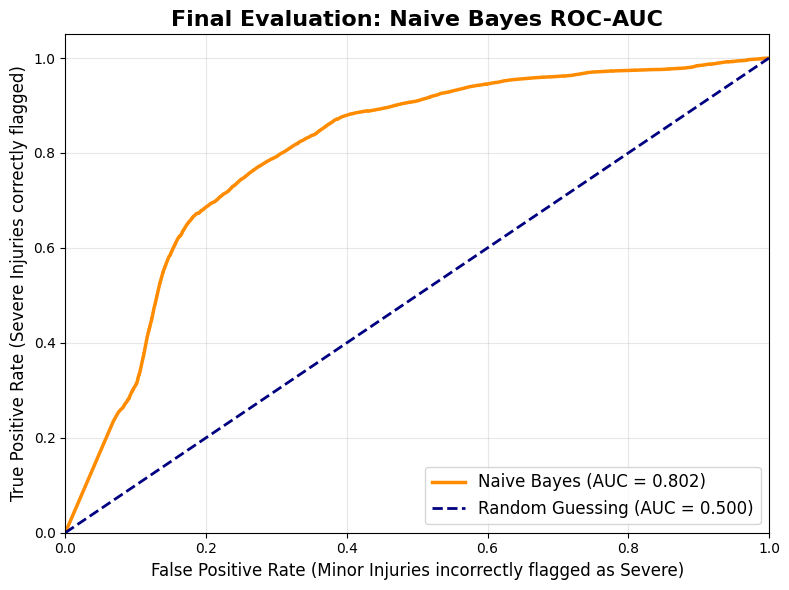

In [7]:


def plot_single_roc(model_pipeline, X_test, y_test, model_name="Final Champion Model"):
    """
    Calculates probabilities and plots the ROC-AUC curve for a single trained model 
    against the Hold-Out Test dataset.
    """
    print(f"Generating Final ROC-AUC Curve for {model_name}...")
    
    # 1. Get the probability that the patient is in the Positive Class (Hospitalized)
    # .predict_proba() returns [Probability_Released, Probability_Hospitalized]
    # We slice [:, 1] to grab only the Hospitalized probabilities.
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]
    
    # 2. Calculate the False Positive Rate (fpr) and True Positive Rate (tpr)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    
    # 3. Calculate the Area Under the Curve (AUC) score
    roc_auc = auc(fpr, tpr)
    
    # 4. Set up the plotting canvas
    plt.figure(figsize=(8, 6))
    
    # 5. Plot the Model's Curve
    # We use a bold color (like dark orange) to make it pop for presentations
    plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

    # 6. Plot the "Coin Flip" Baseline (Random Guessing)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
             label='Random Guessing (AUC = 0.500)')

    # 7. Format the Graph for Professional Presentation
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Minor Injuries incorrectly flagged as Severe)', fontsize=12)
    plt.ylabel('True Positive Rate (Severe Injuries correctly flagged)', fontsize=12)
    plt.title(f'Final Evaluation: {model_name} ROC-AUC', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    
    # 8. Display the Graph
    plt.tight_layout()
    plt.show()

plot_single_roc(naive_bayes, X_eval, y_eval, model_name="Naive Bayes")

### 7. Export Naive Bayes Model

In [8]:
print("Exporting Naive Bayes pipeline to disk...")
model_path = '../models/neiss_naive_bayes.joblib'
joblib.dump(naive_bayes, model_path)
print("Model successfully saved!")

Exporting Naive Bayes pipeline to disk...
Model successfully saved!
